Summary of the five-step procedure from Appendix A of "*What Moves Stock Prices? The Roles of News, Noise, and Information*":

1.   Estimate the reduced-form VAR in Equation (A1), saving the residuals and variance/covariance matrix of residuals;

2.   Estimate the parameters $b_{1,0}$, $c_{1,0}$, and $c_{2,0}$ from regressions of the reduced-form residuals (second and third equations in [A2]);

3.   Estimate the variances of the structural innovations using Equation (A3);
    
4.   Estimate the long-run (permanent) cumulative return responses to unit shocks of the structural-model innovations, $\theta_{rm}$, $\theta_x$, and $\theta_r$, using reduced-form-model impulse response functions with the shocks given in Equations (A4); and
    
5.   Combine the estimated variances of the structural innovations from step (iii) with the long-run return responses from step (iv) to get the variance components and variance shares following Equations (9) and (10) in the paper.

In [ ]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR


# Find the Thesis project root so the notebook works from either Thesis/ or Thesis/Scripts/.
candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
PROJECT_DIR = next(
    (root for root in candidate_roots if (root / "Data").exists() and (root / "Scripts").exists()),
    Path.cwd().resolve(),
)
DATA_DIR = PROJECT_DIR / "Data"
OUTPUTS_DIR = PROJECT_DIR / "Outputs"

# Make sure the output folder exists before any figures are written to disk.
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# @title Run if you want to use same data as last time

# Reuse the processed file stored in Thesis/Data.
processed_path = DATA_DIR / "processed_data.pkl"

with open(processed_path, 'rb') as file_handle:
    data = pickle.load(file_handle)

prices = data['prices']
volume = data['volume']
market_ret = data['market_ret']
index = data['index']

print(f"Loaded data: {len(prices)} dates, {len(prices.columns)} stocks")

Loaded data: 4957 dates, 500 stocks


In [ ]:
# @title Run if you want to use new data set

# Read the Excel file from the reorganized Thesis/Data folder.
file_path = DATA_DIR / "BigSmall_NYA.xlsx"
raw = pd.read_excel(file_path, sheet_name="BigCap")
index = 'NYA Index'

# Parse dates and set them as the index before processing the table.
raw1 = raw.rename(columns={'Unnamed: 0': 'Date'})
dates = pd.to_datetime(raw1['Date'].iloc[1:])

raw1 = raw1.iloc[1:].copy()
raw1['Date'] = dates
raw1 = raw1.set_index('Date')

# Read the second header row so each column can be tagged as PRICE or VOLUME.
second_header = raw.iloc[0]
data = raw1.copy()

# Build a MultiIndex for columns: (ticker, field).
arrays = []
for col in data.columns:
    field = second_header[col]
    ticker = col
    if col.startswith('Unnamed:'):
        idx = data.columns.get_loc(col)
        ticker = data.columns[idx - 1]
    arrays.append((ticker, field))

tuples = [(ticker, field) for ticker, field in arrays]
multi_cols = pd.MultiIndex.from_tuples(tuples, names=['Ticker', 'Field'])
data.columns = multi_cols

# Split the table into prices and volumes.
prices = data.xs('PRICE', axis=1, level='Field')
volume = data.xs('VOLUME', axis=1, level='Field')
market = prices[[index]].copy()

# Keep the same sample window as the script version.
start_date = '1997-01-01'
end_date = '2015-12-31'
date_mask = (prices.index >= start_date) & (prices.index <= end_date)
prices = prices.loc[date_mask]
volume = volume.loc[date_mask]
market = market.loc[date_mask]

# Fill short gaps so returns and volume can be computed consistently.
prices = prices.ffill(limit=5)
volume = volume.ffill(limit=5)
market = market.ffill(limit=5)

# Compute the market return series used later in the notebook.
market_ret = market[index].pct_change(fill_method=None)

# Save the processed objects in Thesis/Data for reuse.
processed_path = DATA_DIR / 'processed_data.pkl'
with open(processed_path, 'wb') as file_handle:
    pickle.dump({
        'prices': prices,
        'volume': volume,
        'market_ret': market_ret,
        'index': index,
    }, file_handle)

print(f"Data saved successfully to {processed_path}!")

/var/folders/6j/nyj137dj6yq6wl36j4x2l0xw0000gn/T/ipykernel_38253/1931620052.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prices = prices.ffill(limit=5)


Data saved successfully!


/var/folders/6j/nyj137dj6yq6wl36j4x2l0xw0000gn/T/ipykernel_38253/1931620052.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  volume = volume.ffill(limit=5)
/var/folders/6j/nyj137dj6yq6wl36j4x2l0xw0000gn/T/ipykernel_38253/1931620052.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  market = market.ffill(limit=5)


In [4]:
# Calculate stock returns for all tickers (excluding market index)
stock_tickers = [col for col in prices.columns if col != index]
returns = prices[stock_tickers].pct_change(fill_method=None)

# Build long-format DataFrame
df_list = []

for ticker in stock_tickers:
    # Get data for this ticker
    ticker_df = pd.DataFrame({
        'date': prices.index,
        'ticker': ticker,
        'price': prices[ticker].values,
        'volume': volume[ticker].values,
        'r': returns[ticker].values * 100,  # Convert to percentage
        'rm': market_ret.values * 100       # Convert to percentage
    })

    df_list.append(ticker_df)

# Concatenate all stocks
df = pd.concat(df_list, ignore_index=True)

# Add year column
df['year'] = df['date'].dt.year

# Remove missing values
df = df.dropna(subset=['r', 'rm', 'price', 'volume'])

# Filter: min observations per stock-year
df = df.groupby(['ticker', 'year']).filter(lambda x: len(x) >= 100)

# Keep only necessary columns in correct order
df = df[['ticker', 'year', 'date', 'rm', 'r', 'volume', 'price']]

print(f"Final dataset shape: {df.shape}")
print(f"Stocks: {df['ticker'].nunique()}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")
print(f"\nFirst few rows:\n{df.head()}")

Final dataset shape: (2472981, 7)
Stocks: 499
Years: 1997-2015

First few rows:
         ticker  year       date        rm         r     volume    price
1  PG US Equity  1997 1997-01-02 -0.706110 -0.929150  5065200.0  26.6563
2  PG US Equity  1997 1997-01-03  1.162720  1.641263  3741200.0  27.0938
3  PG US Equity  1997 1997-01-06  0.055920  0.692040  5544000.0  27.2813
4  PG US Equity  1997 1997-01-07  0.664426  1.832757  3578800.0  27.7813
5  PG US Equity  1997 1997-01-08 -0.415564 -1.799772  5900800.0  27.2813


In [5]:
def decompose_variance_single_stock(df_stock, market_ret_col='rm',
                                   stock_ret_col='r', volume_col='volume',
                                   price_col='price', n_lags=5):
    """
    Decompose variance for a single stock-year following Brogaard et al. (2022).

    Returns dict with variance components and shares, or None if estimation fails.
    """

    # ========================================
    # 1. Prepare data
    # ========================================
    df = df_stock.copy()

    # Calculate signed dollar volume: sign(return) * price * volume
    df['x'] = np.sign(df[stock_ret_col]) * df[price_col] * df[volume_col]

    # Select variables in correct order: [rm, x, r]
    var_data = df[[market_ret_col, 'x', stock_ret_col]].dropna()

    if len(var_data) < 100:  # Minimum observations check
        return None

    # ========================================
    # 2. Estimate reduced-form VAR
    # ========================================
    try:
        var_model = VAR(var_data)
        var_result = var_model.fit(maxlags=n_lags, trend='c')
    except:
        return None

    # Get reduced-form residuals
    resids = var_result.resid
    e_rm = resids.iloc[:, 0]
    e_x = resids.iloc[:, 1]
    e_r = resids.iloc[:, 2]

    # Reduced-form residual variances
    sigma2_erm = np.var(e_rm, ddof=1)
    sigma2_ex = np.var(e_x, ddof=1)
    sigma2_er = np.var(e_r, ddof=1)

    # ========================================
    # 3. Identify structural parameters
    # ========================================
    # From Equation (A2): e_x = b1,0 * e_rm + eps_x
    b10 = np.cov(e_x, e_rm)[0,1] / np.var(e_rm, ddof=1)

    # From Equation (A2): e_r = c1,0 * e_rm + c2,0 * e_x + eps_r
    X_mat = np.column_stack([e_rm, e_x])
    coeffs = np.linalg.lstsq(X_mat, e_r, rcond=None)[0]
    c10, c20 = coeffs

    # ========================================
    # 4. Calculate structural shock variances (Equation A3)
    # ========================================
    sigma2_eps_rm = sigma2_erm
    sigma2_eps_x = sigma2_ex - b10**2 * sigma2_erm
    sigma2_eps_r = (sigma2_er
                    - (c10**2 + 2*c10*c20*b10) * sigma2_erm  # Fixed: added cross-term
                    - c20**2 * sigma2_ex)

    # Ensure non-negative variances
    if sigma2_eps_x < 0 or sigma2_eps_r < 0:
        return None

    # ========================================
    # 5. Calculate impulse responses (Equation A4)
    # ========================================
    horizon = 15  # 3 * n_lags as per paper

    # Structural shocks as reduced-form equivalents
    # Shock 1: market return shock [1, b10, c10+c20*b10]
    shock_rm = np.zeros((horizon, 3))
    shock_rm[0] = [1, b10, c10 + c20*b10]

    # Shock 2: signed volume shock [0, 1, c20]
    shock_x = np.zeros((horizon, 3))
    shock_x[0] = [0, 1, c20]

    # Shock 3: stock return shock [0, 0, 1]
    shock_r = np.zeros((horizon, 3))
    shock_r[0] = [0, 0, 1]

    # Calculate cumulative return responses using VAR coefficients
    def cumulative_response(initial_shock, var_result, horizon):
        """Calculate cumulative impulse response for stock returns (3rd variable)."""
        response = np.zeros(horizon)
        state = initial_shock.copy()

        for t in range(horizon):
            # Get return response (3rd element)
            response[t] = state[2]

            # Update state with VAR dynamics (only use lagged effects after t=0)
            if t < horizon - 1:
                new_state = np.zeros(3)
                for lag in range(1, min(t+2, n_lags+1)):
                    if t - lag + 1 >= 0:
                        lag_idx = lag - 1
                        coef_matrix = var_result.params.iloc[1 + lag_idx*3:1 + (lag_idx+1)*3, :].values
                        # Note: only lagged state matters after initial shock
                        if lag == 1:
                            new_state += coef_matrix.T @ state
                state = new_state

        return np.cumsum(response)

    irf_rm = cumulative_response(shock_rm[0], var_result, horizon)
    irf_x = cumulative_response(shock_x[0], var_result, horizon)
    irf_r = cumulative_response(shock_r[0], var_result, horizon)

    # Long-run (permanent) effects at t=15
    theta_rm = irf_rm[-1]
    theta_x = irf_x[-1]
    theta_r = irf_r[-1]

    # ========================================
    # 6. Calculate variance components (Equation 9)
    # ========================================
    MktInfo = theta_rm**2 * sigma2_eps_rm
    PrivateInfo = theta_x**2 * sigma2_eps_x
    PublicInfo = theta_r**2 * sigma2_eps_r

    # Information variance
    sigma2_w = MktInfo + PrivateInfo + PublicInfo

    # Calculate noise
    a0 = var_result.params.iloc[0, 2]  # Constant from return equation (drift)
    fitted_info_return = (theta_rm * var_result.resid.iloc[:, 0] +
                          theta_x * var_result.resid.iloc[:, 1] +
                          theta_r * var_result.resid.iloc[:, 2])

    noise_returns = var_data[stock_ret_col].values[n_lags:] - a0 - fitted_info_return
    sigma2_s = np.var(noise_returns, ddof=1)

    # Ensure non-negative noise variance
    if sigma2_s < 0:
        sigma2_s = 0

    return {
        'MktInfo': MktInfo,
        'PrivateInfo': PrivateInfo,
        'PublicInfo': PublicInfo,
        'Noise': sigma2_s,
        'sigma2_w': sigma2_w,
        'sigma2_s': sigma2_s,
        'theta_rm': theta_rm,
        'theta_x': theta_x,
        'theta_r': theta_r,
        'b10': b10,
        'c10': c10,
        'c20': c20
    }

In [6]:
def process_stock_year_data(df, stock_col='ticker', year_col='year',
                            market_ret_col='rm', stock_ret_col='r',
                            volume_col='volume', price_col='price'):
    """
    Process all stock-years and calculate variance decomposition.

    Returns DataFrame with variance components and shares.
    """

    results = []

    for (stock, year), group in df.groupby([stock_col, year_col]):
        res = decompose_variance_single_stock(
            group, market_ret_col, stock_ret_col, volume_col, price_col
        )

        if res is not None:
            res['stock'] = stock
            res['year'] = year
            res['n_obs'] = len(group)
            results.append(res)

    results_df = pd.DataFrame(results)

    if len(results_df) == 0:
        return results_df

    # ========================================
    # Winsorize variance components by year (5% and 95%)
    # ========================================
    component_cols = ['MktInfo', 'PrivateInfo', 'PublicInfo', 'Noise']

    for year in results_df['year'].unique():
        year_mask = results_df['year'] == year
        for col in component_cols:
            q05 = results_df.loc[year_mask, col].quantile(0.05)
            q95 = results_df.loc[year_mask, col].quantile(0.95)
            results_df.loc[year_mask, col] = results_df.loc[year_mask, col].clip(lower=q05, upper=q95)

    # ========================================
    # Calculate variance shares (Equation 10)
    # ========================================
    results_df['VarTotal'] = (results_df['MktInfo'] + results_df['PrivateInfo'] +
                              results_df['PublicInfo'] + results_df['Noise'])

    results_df['MktInfoShare'] = 100 * results_df['MktInfo'] / results_df['VarTotal']
    results_df['PrivateInfoShare'] = 100 * results_df['PrivateInfo'] / results_df['VarTotal']
    results_df['PublicInfoShare'] = 100 * results_df['PublicInfo'] / results_df['VarTotal']
    results_df['NoiseShare'] = 100 * results_df['Noise'] / results_df['VarTotal']

    return results_df


def aggregate_variance_shares_fixed(results_df, share_cols=None):
    """
    Calculate equal-weighted and variance-weighted yearly averages.
    """
    if share_cols is None:
        share_cols = ['MktInfoShare', 'PrivateInfoShare', 'PublicInfoShare', 'NoiseShare']

    # Equal-weighted
    EW = results_df.groupby('year')[share_cols].mean()

    # Variance-weighted - robust version
    def vw_avg(group):
        # Remove rows with NaN in shares or weights
        clean_group = group.dropna(subset=share_cols + ['VarTotal'])

        # Remove rows with zero or negative weights
        clean_group = clean_group[clean_group['VarTotal'] > 0]

        if len(clean_group) == 0:
            return pd.Series({col: np.nan for col in share_cols})

        weights = clean_group['VarTotal'].values
        result = {}

        for col in share_cols:
            values = clean_group[col].values
            result[col] = np.average(values, weights=weights)

        return pd.Series(result)

    VW = results_df.groupby('year').apply(vw_avg)

    return EW, VW

# Assuming your data is in df with columns: ticker, year, date, rm, r, volume, price
# where rm = market return, r = stock return

results_df = process_stock_year_data(df)

# Recalculate
EW, VW = aggregate_variance_shares_fixed(results_df)

# Define share_cols globally for the print statements
share_cols = ['MktInfoShare', 'PrivateInfoShare', 'PublicInfoShare', 'NoiseShare']

# Check for issues
print("VW head:\n", VW.head(10))
print("\nVW tail:\n", VW.tail(10))
print("\nVW info:")
print(VW.info())

# Check source data quality
print("\n=== Data Quality Checks ===")
print(f"Total stock-years: {len(results_df)}")
print(f"Stock-years with NaN in shares: {results_df[share_cols].isna().any(axis=1).sum()}")
print(f"Stock-years with NaN in VarTotal: {results_df['VarTotal'].isna().sum()}")
print(f"Stock-years with VarTotal <= 0: {(results_df['VarTotal'] <= 0).sum()}")

print("\nStocks per year:")
print(results_df.groupby('year').size())

print("\nSample of VarTotal by year:")
print(results_df.groupby('year')['VarTotal'].agg(['count', 'mean', 'min', 'max']))

/Users/docx/Thesis/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/docx/Thesis/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/docx/Thesis/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/docx/Thesis/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupport

VW head:
       MktInfoShare  PrivateInfoShare  PublicInfoShare  NoiseShare
year                                                             
1997      7.758849         26.443825        22.052895   43.744431
1998     10.158923         20.854838        25.614821   43.371418
1999      4.133161         29.659639        25.162686   41.044513
2000      6.680770         25.954277        24.429096   42.935857
2001      9.043204         22.246741        22.399937   46.310118
2002     11.248603         18.373442        26.477242   43.900714
2003      8.940355         22.848526        21.115290   47.095829
2004      9.729641         23.326219        19.205861   47.738280
2005      7.394090         25.418352        19.273482   47.914075
2006     10.998641         21.756572        17.057715   50.187071

VW tail:
       MktInfoShare  PrivateInfoShare  PublicInfoShare  NoiseShare
year                                                             
2006     10.998641         21.756572        17.057715  

/var/folders/6j/nyj137dj6yq6wl36j4x2l0xw0000gn/T/ipykernel_38253/1515076370.py:84: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  VW = results_df.groupby('year').apply(vw_avg)


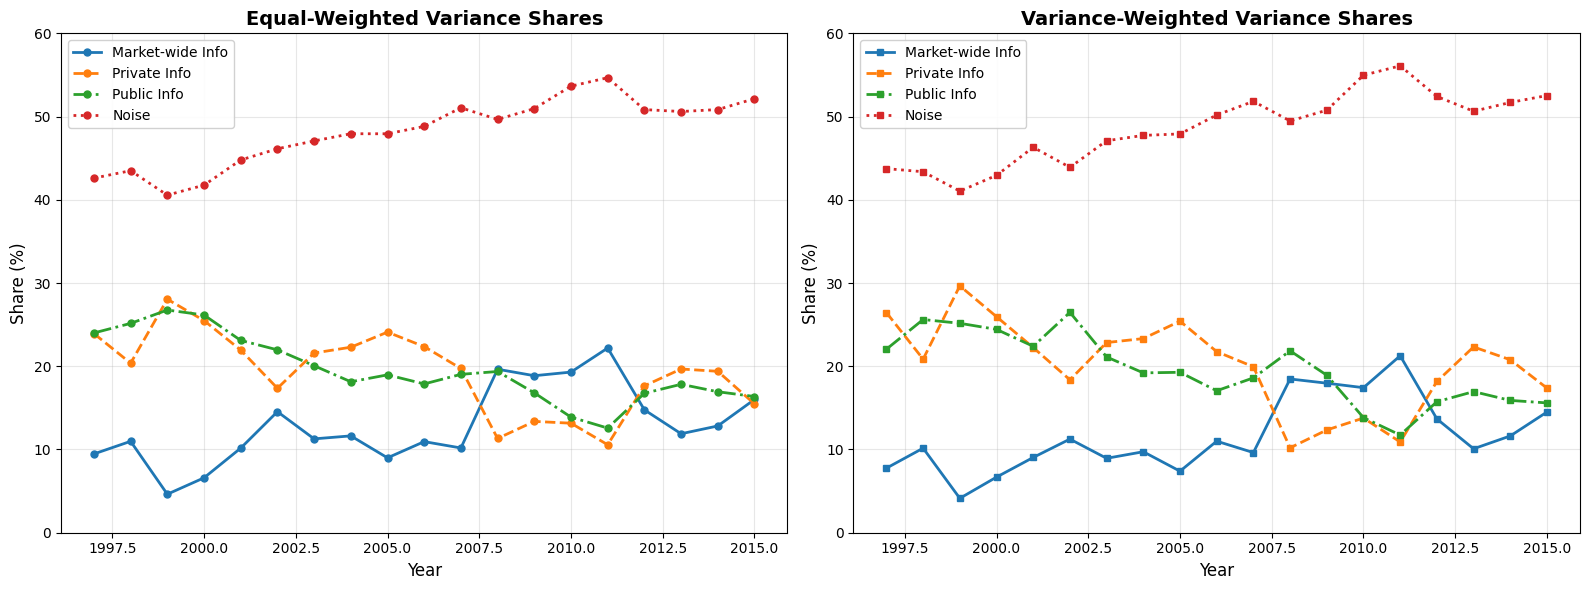


=== VARIANCE-WEIGHTED MEANS (Full Period) ===
MktInfoShare        11.62
PrivateInfoShare    20.14
PublicInfoShare     19.57
NoiseShare          48.67
dtype: float64

=== EQUAL-WEIGHTED MEANS (Full Period) ===
MktInfoShare        12.89
PrivateInfoShare    19.36
PublicInfoShare     19.57
NoiseShare          48.18
dtype: float64


In [7]:
# Plotting code
share_cols = ["MktInfoShare", "PrivateInfoShare", "PublicInfoShare", "NoiseShare"]

colors = {
    "MktInfoShare": "#1f77b4",
    "PrivateInfoShare": "#ff7f0e",
    "PublicInfoShare": "#2ca02c",
    "NoiseShare": "#d62728",
}

linestyles = {
    "MktInfoShare": "-",
    "PrivateInfoShare": "--",
    "PublicInfoShare": "-.",
    "NoiseShare": ":",
}

labels = {
    "MktInfoShare": "Market-wide Info",
    "PrivateInfoShare": "Private Info",
    "PublicInfoShare": "Public Info",
    "NoiseShare": "Noise"
}

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["lines.linewidth"] = 2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Equal-weighted
ax = axes[0]
for col in share_cols:
    ax.plot(EW.index, EW[col],
            label=labels[col],
            color=colors[col],
            linestyle=linestyles[col],
            marker='o',
            markersize=5,
            markevery=1)
ax.set_title("Equal-Weighted Variance Shares", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Share (%)")
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 60])

# Variance-weighted
ax = axes[1]
for col in share_cols:
    ax.plot(VW.index, VW[col],
            label=labels[col],
            color=colors[col],
            linestyle=linestyles[col],
            marker='s',
            markersize=5,
            markevery=1)
ax.set_title("Variance-Weighted Variance Shares", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Share (%)")
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 60])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== VARIANCE-WEIGHTED MEANS (Full Period) ===")
print(VW.mean().round(2))
print("\n=== EQUAL-WEIGHTED MEANS (Full Period) ===")
print(EW.mean().round(2))